In [12]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
data = pd.read_csv(url)

In [15]:
print(data.head())

      crim    zn  indus  chas    nox  ...  tax  ptratio       b  lstat  medv
0  0.00632  18.0   2.31     0  0.538  ...  296     15.3  396.90   4.98  24.0
1  0.02731   0.0   7.07     0  0.469  ...  242     17.8  396.90   9.14  21.6
2  0.02729   0.0   7.07     0  0.469  ...  242     17.8  392.83   4.03  34.7
3  0.03237   0.0   2.18     0  0.458  ...  222     18.7  394.63   2.94  33.4
4  0.06905   0.0   2.18     0  0.458  ...  222     18.7  396.90   5.33  36.2

[5 rows x 14 columns]


In [16]:
X = data.drop("medv", axis=1)
y = data["medv"]

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

In [19]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (404, 13)
Test set shape: (102, 13)


In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [22]:
print("\n--- Linear Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


--- Linear Regression Performance ---
Mean Absolute Error (MAE): 3.1891
Mean Squared Error (MSE): 24.2911
Root Mean Squared Error (RMSE): 4.9286
R² Score: 0.6688


In [23]:
results_df = pd.DataFrame({
    'Regression Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})
print("\n--- Performance Summary ---")
print(results_df.to_string(index=False))


--- Performance Summary ---
Regression Metric     Value
              MAE  3.189092
              MSE 24.291119
             RMSE  4.928602
         R² Score  0.668759


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
data = pd.read_csv(url)

print(data.head())

      crim    zn  indus  chas    nox  ...  tax  ptratio       b  lstat  medv
0  0.00632  18.0   2.31     0  0.538  ...  296     15.3  396.90   4.98  24.0
1  0.02731   0.0   7.07     0  0.469  ...  242     17.8  396.90   9.14  21.6
2  0.02729   0.0   7.07     0  0.469  ...  242     17.8  392.83   4.03  34.7
3  0.03237   0.0   2.18     0  0.458  ...  222     18.7  394.63   2.94  33.4
4  0.06905   0.0   2.18     0  0.458  ...  222     18.7  396.90   5.33  36.2

[5 rows x 14 columns]


In [26]:
X = data.drop("medv", axis=1)
y = data["medv"]

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

In [28]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

svr_preds = svr.predict(X_test)

svr_mse = mean_squared_error(y_test, svr_preds)
svr_r2 = r2_score(y_test, svr_preds)

print("\nSVR Results")
print("MSE:", svr_mse)
print("R2 Score:", svr_r2)


SVR Results
MSE: 25.693036656663203
R2 Score: 0.6496425583214102


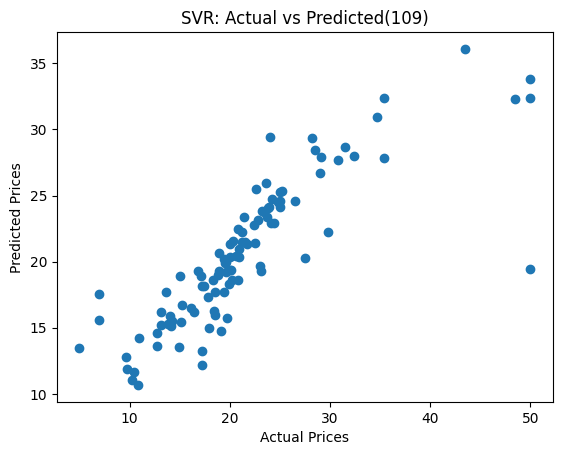

In [29]:
plt.figure()
plt.scatter(y_test, svr_preds)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("SVR: Actual vs Predicted(109)")
plt.show()

In [30]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

print("\nDecision Tree Results")
print("MSE:", dt_mse)
print("R2 Score:", dt_r2)


Decision Tree Results
MSE: 10.416078431372549
R2 Score: 0.8579634380978161


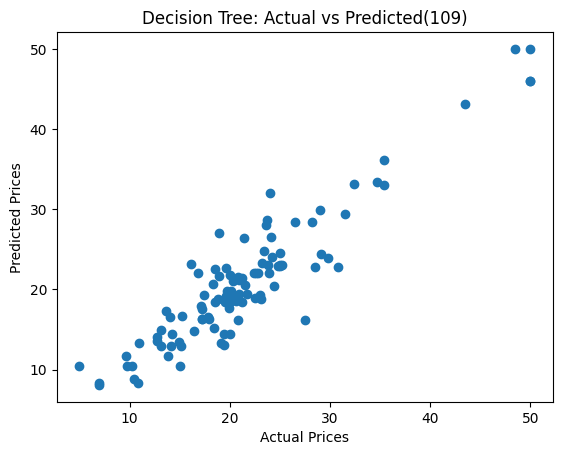

In [32]:
plt.figure()
plt.scatter(y_test, dt_preds)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Decision Tree: Actual vs Predicted(109)")
plt.show()

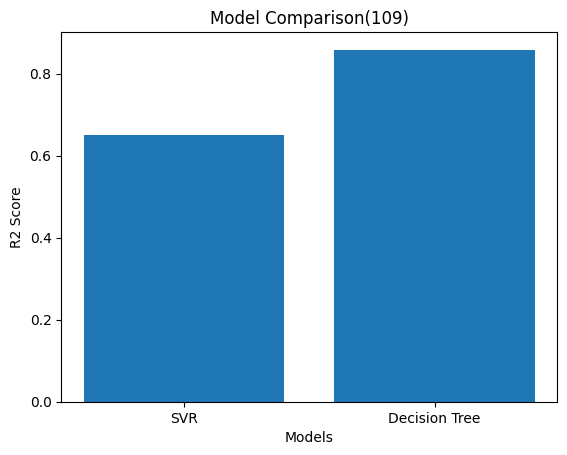

In [33]:
models = ["SVR", "Decision Tree"]
r2_scores = [svr_r2, dt_r2]

plt.figure()
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison(109)")
plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
data = pd.read_csv(url)

X = data.drop("medv", axis=1)
y = data["medv"]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

In [36]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

svr_preds = svr.predict(X_test)

# Metrics
svr_mse = mean_squared_error(y_test, svr_preds)
svr_r2 = r2_score(y_test, svr_preds)

print("\nSVR Performance")
print("MSE:", svr_mse)
print("R2:", svr_r2)


SVR Performance
MSE: 25.693036656663203
R2: 0.6496425583214102


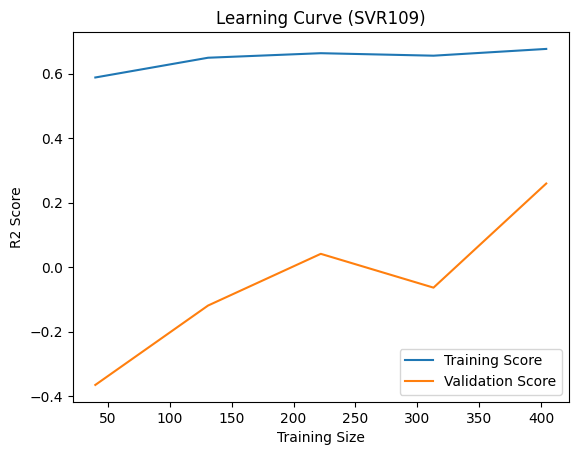

In [38]:
train_sizes, train_scores, test_scores = learning_curve(
    svr, X_scaled, y, cv=5, scoring='r2'
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve (SVR109)")
plt.legend()
plt.show()

In [40]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

print("\nDecision Tree Performance")
print("MSE:", dt_mse)
print("R2:", dt_r2)


Decision Tree Performance
MSE: 10.416078431372549
R2: 0.8579634380978161


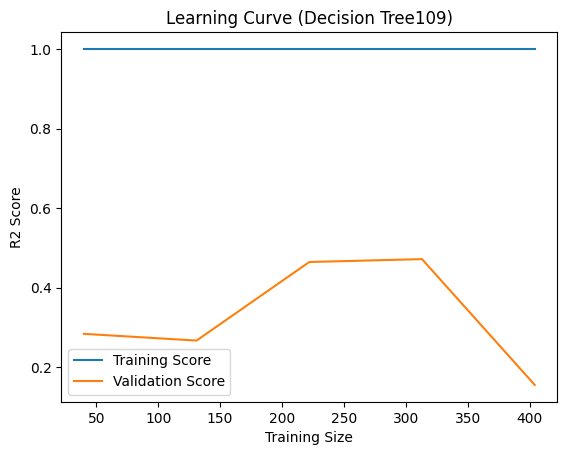

In [42]:
train_sizes, train_scores, test_scores = learning_curve(
    dt, X_scaled, y, cv=5, scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve (Decision Tree109)")
plt.legend()
plt.show()

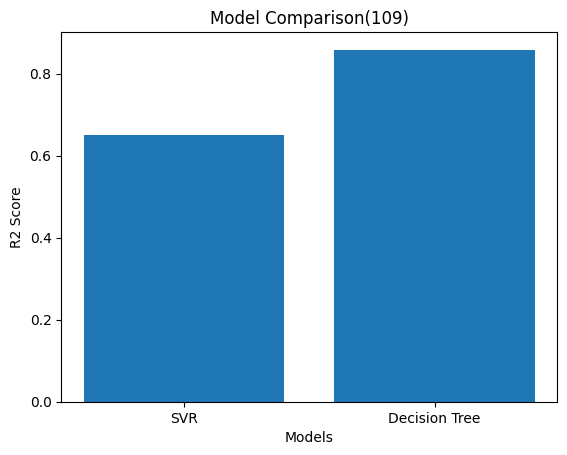

In [43]:
models = ["SVR", "Decision Tree"]
r2_scores = [svr_r2, dt_r2]

plt.figure()
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison(109)")
plt.show()